# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadOmerSiddiqui/myInternship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [8]:
import os, sys, subprocess
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    REPO = "myInternship"
    if not os.path.isdir(REPO):
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/MuhammadOmerSiddiqui/myInternship.git", REPO],
            check=True
        )
    os.chdir(REPO)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining"] = (df["trend_direction"] == "down").astype(int)
print("Loaded", len(df), "pages")

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

Loaded 30000 pages


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

**What the playbook outputs**

A ranked list of pages. Each row has:
- a **score** (model probability blended with a transparent baseline)
- one or more **reason codes** (why it ranked here)
- a **suggested action** (what a human should consider)

**Reason codes**
| Code | Meaning |
|------|---------|
| `stale_visible_page` | Old / not updated recently, still gets impressions |
| `declining_with_demand` | Trend down and still has demand |
| `low_ctr_visible_page` | Visible position but weak CTR |
| `general_refresh_review` | Fallback review signal |

**Actions**
| Action | When |
|--------|------|
| `refresh` | Stale or declining with demand |
| `refresh_and_review_ctr` | Low CTR on a visible page |
| `monitor` | Lower priority — watch only |

This is a **review queue**, not an automatic publish list.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
RANDOM_STATE = 42

# ----- features (honest) -----
numeric_cols = [c for c in [
    "impressions_90d","clicks_90d","sessions_90d","content_age_days",
    "days_since_last_update","avg_position","ctr","engagement_rate","scroll_rate",
    "word_count","char_count","days_with_impressions","days_with_sessions",
    "ai_sessions_90d","ai_traffic_pct"
] if c in df.columns]
cat_cols = [c for c in [
    "content_type","main_intent","competition_level",
    "age_tier","freshness_tier","impression_tier","position_tier"
] if c in df.columns]

X_num = df[numeric_cols].apply(pd.to_numeric, errors="coerce").replace([np.inf,-np.inf],np.nan).fillna(0)
X_cat = pd.get_dummies(df[cat_cols].fillna("unknown").astype(str), dtype=float)
X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1)
y = df["is_declining"].astype(int)

# Client-holdout train for an honest model score
rng = np.random.default_rng(RANDOM_STATE)
clients = df["client_id"].fillna("unknown").astype(str)
uniq = clients.drop_duplicates().to_numpy()
shuf = rng.permutation(uniq)
test_clients = set(shuf[:max(1, int(round(len(shuf)*0.2)))])
test_mask = clients.isin(test_clients).to_numpy()
train_idx = np.where(~test_mask)[0]

rf = RandomForestClassifier(
    class_weight="balanced_subsample", n_estimators=200, max_depth=10,
    min_samples_leaf=25, n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X.iloc[train_idx], y.iloc[train_idx])
model_proba = rf.predict_proba(X)[:, 1]

# Transparent baseline component
def pct_rank(s): return s.rank(pct=True, method="average").fillna(0)
def norm(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

vis   = pct_rank(np.log1p(df["impressions_90d"]))
fresh = pct_rank(df["days_since_last_update"].fillna(0))
pos   = (1 - norm(df["avg_position"].clip(1, 50))) * vis * (df["avg_position"] > 0).astype(int)
depth = (1 - pct_rank(df["word_count"].fillna(0))) * vis
baseline = (0.40*vis + 0.30*fresh + 0.25*pos + 0.05*depth).clip(0, 1)

# Final playbook score: mostly model, some baseline for stability
final_score = (0.70 * model_proba + 0.30 * baseline.values)

def reason_codes(row):
    r = []
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        r.append("stale_visible_page")
    if str(row["trend_direction"]).lower() == "down" and row["impressions_90d"] >= 100:
        r.append("declining_with_demand")
    if row["impressions_90d"] >= 500 and 0 < row["avg_position"] <= 20 and row["ctr"] < 0.5:
        r.append("low_ctr_visible_page")
    if not r:
        r.append("general_refresh_review")
    return "|".join(r)

def suggested_action(codes):
    s = set(codes.split("|"))
    if "low_ctr_visible_page" in s:
        return "refresh_and_review_ctr"
    if "stale_visible_page" in s or "declining_with_demand" in s:
        return "refresh"
    return "monitor"

queue = df[["content_id","client_id","impressions_90d","avg_position","ctr",
            "content_age_days","days_since_last_update","trend_direction",
            "word_count","sessions_90d"]].copy()
queue["model_proba"] = model_proba
queue["baseline_score"] = baseline.values
queue["final_score"] = final_score
queue["is_declining"] = y.values
queue["reason_codes"] = queue.apply(reason_codes, axis=1)
queue["suggested_action"] = queue["reason_codes"].map(suggested_action)
queue = queue.sort_values("final_score", ascending=False).reset_index(drop=True)
queue["rank"] = np.arange(1, len(queue)+1)

# Simple confidence band
p80 = queue["final_score"].quantile(0.80)
queue["confidence"] = np.where(
    (queue["final_score"] >= p80) & (queue["impressions_90d"] >= 500),
    "high",
    np.where(queue["final_score"] >= queue["final_score"].median(), "medium", "low")
)

print("Action mix:")
display(queue["suggested_action"].value_counts().to_frame("n"))
print("\nTop 10 of the playbook:")
display(queue.head(10)[["rank","final_score","confidence","suggested_action",
                        "reason_codes","impressions_90d","avg_position","ctr"]])

Action mix:


,n
suggested_action,
monitor,13208
refresh_and_review_ctr,9759
refresh,7033



Top 10 of the playbook:


,rank,final_score,confidence,suggested_action,reason_codes,impressions_90d,avg_position,ctr
0,1,0.788885,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,2846,2.0,0.14
1,2,0.787426,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,2498,10.1,0.00
2,3,0.786792,high,refresh,declining_with_demand,2765,21.1,0.04
3,4,0.785804,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,3393,3.6,0.09
4,5,0.785547,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,22537,15.9,0.36
5,6,0.780932,high,refresh,declining_with_demand,2870,22.1,0.00
6,7,0.780319,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,10575,1.9,0.13
7,8,0.780036,high,refresh,declining_with_demand,22949,23.6,0.08
8,9,0.779668,high,refresh,declining_with_demand,24516,26.9,0.09
9,10,0.779020,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,2748,18.7,0.07


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Who uses this**  
A content editor or SEO specialist with limited weekly review capacity.

**Intended use**
1. Open the ranked queue (high confidence first).
2. Read the reason codes.
3. Open the live page and apply business context.
4. Decide: refresh, expand, tweak title/meta, merge, or monitor.

**Where it stops being valid**
- Not a production auto-publisher.
- Not proof that a refresh will recover traffic.
- Not a Google-algorithm predictor.
- Built on a 30k anonymized starter snapshot; re-validate before any larger rollout.
- Proxy label is current-window decline, not a true future outcome.

**Cost / value thinking**
- Cost of a false positive: editor time on a page that did not need work.
- Cost of a false negative: a high-demand page keeps decaying unnoticed.
- Value of the system: better ordering of limited human hours (decision-support).

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("High-confidence rows:", int((queue["confidence"]=="high").sum()))
print("Share of top-50 that are declining (observed):",
      round(queue.head(50)["is_declining"].mean(), 3))

High-confidence rows: 5323
Share of top-50 that are declining (observed): 0.98


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human review checklist (before acting on a top row)**
1. Is demand real (enough impressions), or noise?
2. Could the drop be seasonality or a sibling page consolidating traffic?
3. Was this page already refreshed recently (snapshot lag)?
4. Is low CTR normal for this intent / position band?
5. Is the page strategic (brand, conversion) even if the score is mid-tier?

**No-go list — do NOT automate**
- Auto-publishing rewritten content from the score alone
- Auto-deleting / pruning pages without human review
- Treating the score as proof of causation
- Using the queue on a new client without re-checking client-holdout performance
- Shipping product decisions from leaked features or private identifiers

**Archetype → action mapping (light)**
| Observed pattern | Suggested human action |
|------------------|------------------------|
| Stale + visible | Refresh / update core sections |
| Declining + demand | Refresh + check internal links / intent match |
| Low CTR + visible | Review title, meta, snippet promise |
| High score but stable/up | Monitor only — possible false positive |
| Low volume | Usually deprioritize unless strategic |

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("Sample of high-confidence refresh candidates:")
display(
    queue[(queue["confidence"]=="high") & (queue["suggested_action"]!="monitor")]
    .head(8)[["rank","suggested_action","reason_codes","impressions_90d","ctr","content_age_days"]]
)

Sample of high-confidence refresh candidates:


,rank,suggested_action,reason_codes,impressions_90d,ctr,content_age_days
0,1,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,2846,0.14,106
1,2,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,2498,0.00,165
2,3,refresh,declining_with_demand,2765,0.04,165
3,4,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,3393,0.09,131
4,5,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,22537,0.36,147
5,6,refresh,declining_with_demand,2870,0.00,124
6,7,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page,10575,0.13,124
7,8,refresh,declining_with_demand,22949,0.08,132


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**When to re-score the queue**
- Fresh data lands (new 90-day snapshot) — at least monthly.
- Major site migration, redesign, or bulk content change.
- Editorial process changes (what “refresh” means operationally).

**When to retrain / revisit the model**
- Precision@50 on a new client-holdout drops materially vs the last logged number.
- Base rate of the declining proxy shifts a lot (portfolio mix change).
- Feature availability changes (new tracking, missing GA4 for many clients).
- Reason codes stop matching what editors actually find useful (feedback loop).

**Light monitoring metrics to log**
- Precision@50 (and base rate) on client-holdout
- Share of top-50 that editors mark “useful”
- Action mix drift (too many `monitor` or too many `refresh`)

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Receipt metrics for the paper / monitoring log
receipt = {
    "n_pages": int(len(queue)),
    "declining_rate": float(queue["is_declining"].mean()),
    "top50_declining_rate": float(queue.head(50)["is_declining"].mean()),
    "action_mix": queue["suggested_action"].value_counts().to_dict(),
    "confidence_mix": queue["confidence"].value_counts().to_dict(),
    "split": "client_holdout_train_then_score_all",
    "score_formula": "0.70 * model_proba + 0.30 * baseline",
}
print(json.dumps(receipt, indent=2))
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(receipt, f, indent=2)
print("Wrote work/outputs/playbook_metrics.json")

{
  "n_pages": 30000,
  "declining_rate": 0.5420666666666667,
  "top50_declining_rate": 0.98,
  "action_mix": {
    "monitor": 13208,
    "refresh_and_review_ctr": 9759,
    "refresh": 7033
  },
  "confidence_mix": {
    "low": 15000,
    "medium": 9677,
    "high": 5323
  },
  "split": "client_holdout_train_then_score_all",
  "score_formula": "0.70 * model_proba + 0.30 * baseline"
}
Wrote work/outputs/playbook_metrics.json


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exports the paper will reuse:
- Ranked queue sample (top rows) → `work/outputs/action_playbook_queue.csv`
- Metrics receipt → `work/outputs/playbook_metrics.json`
- Action-mix figure → `work/figures/action_mix.png`

CSV stays local / regenerable (git may block data files). Commit the figure and JSON.

Wrote work/outputs/action_playbook_queue.csv | rows: 30000


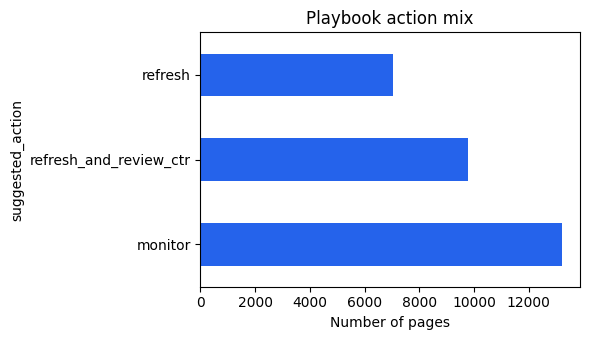

Wrote work/figures/action_mix.png
Wrote work/outputs/playbook_top15_preview.csv


In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Full ranked export (for local use / paper tables)
export_cols = [
    "rank","content_id","final_score","confidence","suggested_action","reason_codes",
    "impressions_90d","avg_position","ctr","content_age_days","days_since_last_update",
    "trend_direction","is_declining","model_proba","baseline_score"
]
queue[export_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print("Wrote work/outputs/action_playbook_queue.csv | rows:", len(queue))

# Figure: action mix
fig, ax = plt.subplots(figsize=(6, 3.5))
queue["suggested_action"].value_counts().plot(kind="barh", ax=ax, color="#2563eb")
ax.set_xlabel("Number of pages")
ax.set_title("Playbook action mix")
plt.tight_layout()
plt.savefig("work/figures/action_mix.png", dpi=120)
plt.show()
print("Wrote work/figures/action_mix.png")

# Small public-safe top-15 preview for the paper
queue.head(15)[export_cols].to_csv("work/outputs/playbook_top15_preview.csv", index=False)
print("Wrote work/outputs/playbook_top15_preview.csv")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.